<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 1 - Phase 1 - Melina

## Extract country codes from NOW text filenames

In [2]:
from pathlib import Path
import re

now_text_dir = Path("corpus/01_now_dataset/02_now_text")

# Matches filenames like:
# - 21-07-ie.txt
# - 22-06-gb.txt
# - 21-07-us1.txt / 21-07-us2.txt -> captures "us"
filename_pattern = re.compile(r"^\d{2}-\d{2}-([a-z]{2})(?:\d+)?\.txt$")

country_codes = {
    match.group(1)
    for file_path in now_text_dir.rglob("*.txt")
    if (match := filename_pattern.match(file_path.name))
}

country_codes

{'au',
 'bd',
 'ca',
 'gb',
 'gh',
 'hk',
 'ie',
 'in',
 'jm',
 'ke',
 'lk',
 'my',
 'ng',
 'nz',
 'ph',
 'pk',
 'sg',
 'tz',
 'us',
 'xx',
 'za'}

## Create `df_palestine_now` from organised NOW corpus paths

In [3]:
from pathlib import Path

import pandas as pd


corpus_dir = Path("corpus/02_now_organised")

records = []

for filepath in sorted(corpus_dir.glob("*/*/*.txt")):
    relative_filepath = filepath.as_posix()
    relative_parts = filepath.relative_to(corpus_dir).parts

    group = relative_parts[0]
    country_code = relative_parts[1]
    article_id = filepath.stem

    records.append(
        {
            "article_id": article_id,
            "group": group,
            "country_code": country_code,
            "filepath": relative_filepath,
        }
    )

df_palestine_now = pd.DataFrame(
    records,
    columns=["article_id", "group", "country_code", "filepath"],
)

df_palestine_now

,article_id,group,country_code,filepath
0,102151649,global_north_2023_09,au,corpus/02_now_organised/global_north_2023_09/a...
1,101440208,global_north_2023_09,ca,corpus/02_now_organised/global_north_2023_09/c...
2,101598939,global_north_2023_09,ca,corpus/02_now_organised/global_north_2023_09/c...
3,101651890,global_north_2023_09,ca,corpus/02_now_organised/global_north_2023_09/c...
4,101993957,global_north_2023_09,ca,corpus/02_now_organised/global_north_2023_09/c...
...,...,...,...,...
117514,126451511,global_south_2025_06,za,corpus/02_now_organised/global_south_2025_06/z...
117515,126476146,global_south_2025_06,za,corpus/02_now_organised/global_south_2025_06/z...
117516,126476212,global_south_2025_06,za,corpus/02_now_organised/global_south_2025_06/z...
117517,126480975,global_south_2025_06,za,corpus/02_now_organised/global_south_2025_06/z...


## Export `df_palestine_now` dataset files

In [4]:
from pathlib import Path


output_dir = Path("corpus")
output_dir.mkdir(parents=True, exist_ok=True)

output_base = output_dir / "palestine_now"

df_palestine_now.to_json(
    f"{output_base}.ndjson",
    orient="records",
    lines=True,
    force_ascii=False,
)

df_palestine_now.to_csv(
    f"{output_base}.tsv",
    sep="\t",
    index=False,
    encoding="utf-8",
)

df_palestine_now.to_excel(
    f"{output_base}.xlsx",
    index=False,
)

print(f"Exported {len(df_palestine_now):,} rows to:")
print(f"- {output_base}.ndjson")
print(f"- {output_base}.tsv")
print(f"- {output_base}.xlsx")

Exported 117,519 rows to:
- corpus/palestine_now.ndjson
- corpus/palestine_now.tsv
- corpus/palestine_now.xlsx


## Inspect the `df_palestine_now_screened` dataset

Import `palestine_now_screened.ndjson.gz` and select the columns of interest

In [1]:
import pandas as pd

screened_path = (
    "corpus/03_now_screened/"
    "llm_screening_v2_gpt-5.6-luna/"
    "palestine_now_screened.ndjson.gz"
)

df_raw = pd.read_json(
    screened_path,
    lines=True,
    compression="gzip"
)

screening_cols = pd.json_normalize(
    df_raw["llm_screening"]
).add_prefix("llm_screening__")

metadata_cols = pd.json_normalize(
    df_raw["llm_screening_metadata"]
).add_prefix("llm_screening_metadata__")

df_palestine_now_screened = pd.concat(
    [
        df_raw.drop(columns=["llm_screening", "llm_screening_metadata"]),
        screening_cols,
        metadata_cols,
    ],
    axis=1,
)

df_palestine_now_screened[
    [
        "article_id",
        "group",
        "country_code",
        "llm_screening__category",
        "llm_screening__gaza_role",
        "llm_screening__confidence",
        "llm_screening__recommended_for_main_corpus",
    ]
].head()

,article_id,group,country_code,llm_screening__category,llm_screening__gaza_role,llm_screening__confidence,llm_screening__recommended_for_main_corpus
0,102151649,global_north_2023_09,au,CORE,substantial,0.99,True
1,101440208,global_north_2023_09,ca,PERIPHERAL,background,0.94,False
2,101598939,global_north_2023_09,ca,PERIPHERAL,background,0.98,False
3,101651890,global_north_2023_09,ca,PERIPHERAL,passing,0.91,False
4,101993957,global_north_2023_09,ca,CORE,background,0.98,True


Inspect counts for `recommended_for_main_corpus`

In [2]:
df_palestine_now_screened[
    "llm_screening__recommended_for_main_corpus"
].value_counts(dropna=False)

llm_screening__recommended_for_main_corpus
True     71422
False    46097
Name: count, dtype: int64

Recommended main corpus subset

In [4]:
df_palestine_now_main = df_palestine_now_screened.loc[
    df_palestine_now_screened["llm_screening__recommended_for_main_corpus"].eq(True)
].copy()

df_palestine_now_main

,article_id,group,country_code,filepath,llm_screening__category,llm_screening__confidence,llm_screening__gaza_role,llm_screening__main_topic,llm_screening__conflict_relevance,llm_screening__reason,...,llm_screening_metadata__temperature,llm_screening_metadata__temperature_sent_to_api,llm_screening_metadata__max_output_tokens,llm_screening_metadata__max_output_tokens_sent_to_api,llm_screening_metadata__usage.input_tokens,llm_screening_metadata__usage.input_tokens_details.cache_write_tokens,llm_screening_metadata__usage.input_tokens_details.cached_tokens,llm_screening_metadata__usage.output_tokens,llm_screening_metadata__usage.output_tokens_details.reasoning_tokens,llm_screening_metadata__usage.total_tokens
0,102151649,global_north_2023_09,au,corpus/02_now_organised/global_north_2023_09/a...,CORE,0.99,substantial,"The Oslo Accords, Israeli-Palestinian peace ne...",The article is centrally focused on Israel/Pal...,This is a sustained analysis of the Israeli-Pa...,...,0.0,False,500,True,1933,1930,0,299,114,2232
4,101993957,global_north_2023_09,ca,corpus/02_now_organised/global_north_2023_09/c...,CORE,0.98,background,Israel-Saudi normalization negotiations and th...,The article directly addresses Israeli-Palesti...,Although the primary focus is the proposed Isr...,...,0.0,False,500,True,1618,1615,0,252,75,1870
5,101994421,global_north_2023_09,ca,corpus/02_now_organised/global_north_2023_09/c...,CORE,0.99,substantial,Israeli pinkwashing and its relationship to th...,The article centrally discusses Israel/Palesti...,The article is primarily about how LGBTQ+ righ...,...,0.0,False,500,True,2296,2293,0,175,0,2471
11,102158043,global_north_2023_09,ca,corpus/02_now_organised/global_north_2023_09/c...,CORE,0.99,substantial,Saudi Arabia's appointment of its first ambass...,The article directly concerns Palestine-relate...,The article is centrally about diplomatic enga...,...,0.0,False,500,True,978,0,0,164,0,1142
12,101631126,global_north_2023_09,gb,corpus/02_now_organised/global_north_2023_09/g...,CORE,1.00,central,Resumption of commercial exports from Gaza thr...,The article directly addresses Gaza's blockade...,Gaza and Israel's restrictions on movement of ...,...,0.0,False,500,True,969,0,0,169,0,1138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117513,126415372,global_south_2025_06,za,corpus/02_now_organised/global_south_2025_06/z...,CORE,0.98,background,Israeli settler violence and clashes with Pale...,"The article directly covers occupation, settle...",Although the immediate focus is violence and a...,...,0.0,False,1000,True,1288,1285,0,250,86,1538
117514,126451511,global_south_2025_06,za,corpus/02_now_organised/global_south_2025_06/z...,CORE,0.99,central,Controversy over discriminatory vetting and ex...,The article directly discusses UCT's Gaza Reso...,The article is centrally concerned with how Is...,...,0.0,False,1000,True,1790,1787,0,236,55,2026
117516,126476212,global_south_2025_06,za,corpus/02_now_organised/global_south_2025_06/z...,CORE,0.99,substantial,BBC's broadcast of Bob Vylan's pro-Palestinian...,The article directly concerns public expressio...,The central subject is a Glastonbury performan...,...,0.0,False,1000,True,1398,1395,0,177,0,1575
117517,126480975,global_south_2025_06,za,corpus/02_now_organised/global_south_2025_06/z...,CORE,0.94,substantial,South Africa's foreign-policy choices followin...,The article directly discusses the Israel-Iran...,Although focused primarily on South Africa-Ira...,...,0.0,False,1000,True,1424,1421,0,303,122,1727


Add `word_count` column to main corpus subset

In [5]:
import re
from pathlib import Path

project_dir = Path(".")  # use this if your notebook is running from cl_st1_ph1_melina

def count_words_from_file(filepath):
    path = project_dir / filepath

    try:
        text = path.read_text(encoding="utf-8", errors="replace")
    except FileNotFoundError:
        return None

    text = re.sub(r"\s*<[^>]+>\s*", " ", text)
    text = re.sub(r"@@\d+", " ", text)

    return len(re.findall(r"\b[\w]+(?:[-'][\w]+)*\b", text))


df_palestine_now_main["word_count"] = (
    df_palestine_now_main["filepath"]
    .apply(count_words_from_file)
)

cols = list(df_palestine_now_main.columns)
cols.remove("word_count")

filepath_pos = cols.index("filepath")
cols = cols[: filepath_pos + 1] + ["word_count"] + cols[filepath_pos + 1:]

df_palestine_now_main = df_palestine_now_main[cols]

df_palestine_now_main[["article_id", "filepath", "word_count"]].head()

,article_id,filepath,word_count
0,102151649,corpus/02_now_organised/global_north_2023_09/a...,989
4,101993957,corpus/02_now_organised/global_north_2023_09/c...,781
5,101994421,corpus/02_now_organised/global_north_2023_09/c...,1179
11,102158043,corpus/02_now_organised/global_north_2023_09/c...,292
12,101631126,corpus/02_now_organised/global_north_2023_09/g...,295


Export the recommended main corpus as NDJSON, TSV, and XLSX files

In [15]:
from pathlib import Path

output_dir = Path("corpus")
output_dir.mkdir(parents=True, exist_ok=True)

ndjson_gz_path = output_dir / "palestine_now_main.ndjson.gz"
tsv_path = output_dir / "palestine_now_main.tsv"
xlsx_path = output_dir / "palestine_now_main.xlsx"

df_palestine_now_main.to_json(
    ndjson_gz_path,
    orient="records",
    lines=True,
    force_ascii=False,
    compression="gzip",
)

df_palestine_now_main.to_csv(
    tsv_path,
    sep="\t",
    index=False,
    encoding="utf-8",
)

df_palestine_now_main.to_excel(
    xlsx_path,
    index=False,
)

print("Exported files:")
print(f"- {ndjson_gz_path}")
print(f"- {tsv_path}")
print(f"- {xlsx_path}")

Exported files:
- corpus/palestine_now_main.ndjson.gz
- corpus/palestine_now_main.tsv
- corpus/palestine_now_main.xlsx


Descriptive statistics on the `word_count` column

In [6]:
df_palestine_now_main["word_count"].describe()

count    71422.000000
mean       811.138711
std        816.151124
min         82.000000
25%        374.000000
50%        630.000000
75%        988.000000
max      20536.000000
Name: word_count, dtype: float64

count    71422.000000
mean       811.138711
std        816.151124
min         82.000000
25%        374.000000
50%        630.000000
75%        988.000000
max      20536.000000
Name: word_count, dtype: float64

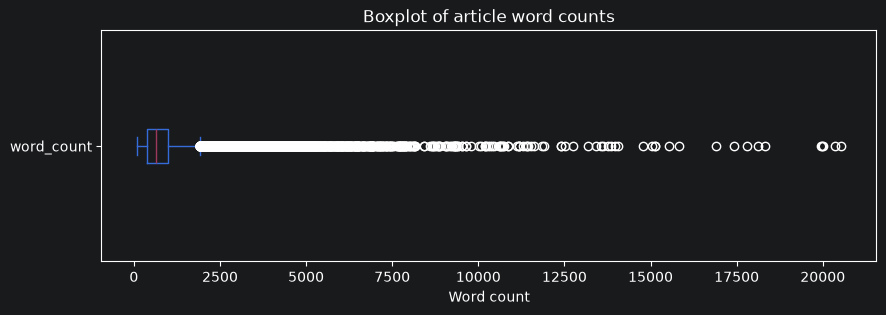

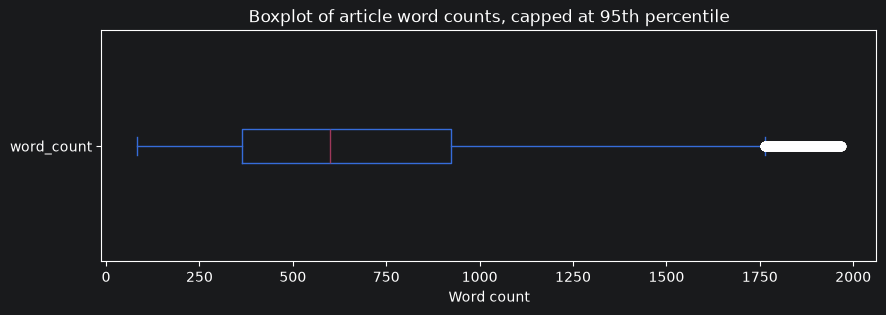

In [8]:
import matplotlib.pyplot as plt

word_counts = df_palestine_now_main["word_count"]

display(word_counts.describe())

word_counts.plot(kind="box", vert=False, figsize=(10, 3))
plt.title("Boxplot of article word counts")
plt.xlabel("Word count")
plt.show()

word_counts[word_counts <= word_counts.quantile(0.95)].plot(
    kind="box",
    vert=False,
    figsize=(10, 3)
)

plt.title("Boxplot of article word counts, capped at 95th percentile")
plt.xlabel("Word count")
plt.show()

Number of articles within the interquartile range per group

In [9]:
q1 = df_palestine_now_main["word_count"].quantile(0.25)
q3 = df_palestine_now_main["word_count"].quantile(0.75)

df_palestine_now_main_iqr = df_palestine_now_main[
    df_palestine_now_main["word_count"].between(q1, q3, inclusive="both")
].copy()

df_iqr_articles_per_group = (
    df_palestine_now_main_iqr
    .groupby("group", dropna=False)
    .size()
    .reset_index(name="n_articles")
    .sort_values("group")
    .reset_index(drop=True)
)

df_iqr_articles_per_group

,group,n_articles
0,global_north_2023_09,25
1,global_north_2023_10,2864
2,global_north_2023_11,1996
3,global_north_2023_12,1113
4,global_north_2024_01,875
5,global_north_2024_02,900
6,global_north_2024_03,880
7,global_north_2024_04,1037
8,global_north_2024_05,1213
9,global_north_2024_06,709


In [13]:
df_iqr_articles_per_group["n_articles"].describe()

count      44.000000
mean      813.204545
std       558.635197
min        10.000000
25%       405.000000
50%       699.000000
75%      1110.750000
max      2864.000000
Name: n_articles, dtype: float64

Total number of articles within the interquartile range

In [12]:
df_iqr_summary = pd.DataFrame({
    "subset": ["within_iqr"],
    "q1_word_count": [q1],
    "q3_word_count": [q3],
    "n_articles": [len(df_palestine_now_main_iqr)],
})

df_iqr_summary

,subset,q1_word_count,q3_word_count,n_articles
0,within_iqr,374.0,988.0,35781


**Following the discussion in [Corpus Sampling and Analysis Strategy](https://github.com/laelgelc/cl_st1_melina/blob/main/cl_st1_ph1_melina/docs/corpus_sampling_and_analysis_strategy.md#corpus-sampling-and-analysis-strategy), since the mean quantity of articles within the interquartile range is 813.204545, we define the cap at 815 articles.**

## Flag Articles Within the Word Count IQR

In [17]:
q1_word_count = df_palestine_now_main["word_count"].quantile(0.25)
q3_word_count = df_palestine_now_main["word_count"].quantile(0.75)

df_palestine_now_main["within_word_count_iqr"] = (
    df_palestine_now_main["word_count"]
    .between(q1_word_count, q3_word_count, inclusive="both")
)

cols = list(df_palestine_now_main.columns)
cols.remove("within_word_count_iqr")

word_count_pos = cols.index("word_count")
cols = (
        cols[: word_count_pos + 1]
        + ["within_word_count_iqr"]
        + cols[word_count_pos + 1:]
)

df_palestine_now_main = df_palestine_now_main[cols]

print(f"Q1 word count: {q1_word_count}")
print(f"Q3 word count: {q3_word_count}")
print(
    "Articles within word count IQR:",
    df_palestine_now_main["within_word_count_iqr"].sum(),
)

df_palestine_now_main[
    ["article_id", "filepath", "word_count", "within_word_count_iqr"]
].head()

Q1 word count: 374.0
Q3 word count: 988.0
Articles within word count IQR: 35781


,article_id,filepath,word_count,within_word_count_iqr
0,102151649,corpus/02_now_organised/global_north_2023_09/a...,989,False
4,101993957,corpus/02_now_organised/global_north_2023_09/c...,781,True
5,101994421,corpus/02_now_organised/global_north_2023_09/c...,1179,False
11,102158043,corpus/02_now_organised/global_north_2023_09/c...,292,False
12,101631126,corpus/02_now_organised/global_north_2023_09/g...,295,False


## Flag IQR Articles Selected by Reproducible Group Cap

In [19]:
cap_per_group = 815
random_state = 42

df_palestine_now_main["within_word_count_iqr_cap"] = False

capped_iqr_indices = (
    df_palestine_now_main[df_palestine_now_main["within_word_count_iqr"]]
    .groupby("group", group_keys=False)
    .apply(
        lambda group_df: group_df.sample(
            n=min(len(group_df), cap_per_group),
            random_state=random_state,
        )
    )
    .index
)

df_palestine_now_main.loc[capped_iqr_indices, "within_word_count_iqr_cap"] = True

cols = list(df_palestine_now_main.columns)
cols.remove("within_word_count_iqr_cap")

within_iqr_pos = cols.index("within_word_count_iqr")
cols = (
        cols[: within_iqr_pos + 1]
        + ["within_word_count_iqr_cap"]
        + cols[within_iqr_pos + 1:]
)

df_palestine_now_main = df_palestine_now_main[cols]

df_iqr_cap_articles_per_group = (
    df_palestine_now_main[df_palestine_now_main["within_word_count_iqr_cap"]]
    .groupby("group", dropna=False)
    .size()
    .reset_index(name="n_articles_iqr_cap")
    .sort_values("group")
    .reset_index(drop=True)
)

print(f"Cap per group: {cap_per_group}")
print(f"Random state: {random_state}")
print(
    "Articles selected within word count IQR cap:",
    df_palestine_now_main["within_word_count_iqr_cap"].sum(),
)

df_iqr_cap_articles_per_group

Cap per group: 815
Random state: 42
Articles selected within word count IQR cap: 26528


,group,n_articles_iqr_cap
0,global_north_2023_09,25
1,global_north_2023_10,815
2,global_north_2023_11,815
3,global_north_2023_12,815
4,global_north_2024_01,815
5,global_north_2024_02,815
6,global_north_2024_03,815
7,global_north_2024_04,815
8,global_north_2024_05,815
9,global_north_2024_06,709


Export the enriched recommended main corpus as NDJSON, TSV, and XLSX files

In [20]:
from pathlib import Path

output_dir = Path("corpus")
output_dir.mkdir(parents=True, exist_ok=True)

ndjson_gz_path = output_dir / "palestine_now_main.ndjson.gz"
tsv_path = output_dir / "palestine_now_main.tsv"
xlsx_path = output_dir / "palestine_now_main.xlsx"

df_palestine_now_main.to_json(
    ndjson_gz_path,
    orient="records",
    lines=True,
    force_ascii=False,
    compression="gzip",
)

df_palestine_now_main.to_csv(
    tsv_path,
    sep="\t",
    index=False,
    encoding="utf-8",
)

df_palestine_now_main.to_excel(
    xlsx_path,
    index=False,
)

print("Exported files:")
print(f"- {ndjson_gz_path}")
print(f"- {tsv_path}")
print(f"- {xlsx_path}")

Exported files:
- corpus/palestine_now_main.ndjson.gz
- corpus/palestine_now_main.tsv
- corpus/palestine_now_main.xlsx
